## Imports and device

In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from body_diode_hybrid import (
    BodyDiodeNN,
    LumpedChargeParameters,
    load_ibd_csv,
    train_ibd_network,
    predict_ibd,
    save_ibd_model,
    simulate_hybrid_body_diode,
)

torch.manual_seed(42)
np.random.seed(42)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("device =", device)

device = cpu


## Cell 2 — Configuration
Change only the file path / column names if your measured CSV uses different names.

In [8]:
DATA_FILE = Path("Ibd_data_template.csv")

VGS_COL = "Vgs"
VDS_COL = "Vds"
IBD_COL = "Ibd"

EPOCHS = 5000
LEARNING_RATE = 1e-3
BATCH_SIZE = 128
VAL_FRACTION = 0.20
SEED = 42

MODEL_FILE = Path("NN_Ibd.pth")

print("DATA_FILE =", DATA_FILE.resolve())

DATA_FILE = C:\Users\zipeng\Desktop\NNProject\Neural-Network_Internship_2026\.github\src\Ibd_data_template.csv


## Cell 3 — Load measured static body-diode data
Required CSV columns: `Vgs, Vds, Ibd`.

In [9]:
df, Vgs, Vds, Ibd = load_ibd_csv(
    DATA_FILE,
    vgs_col=VGS_COL,
    vds_col=VDS_COL,
    ibd_col=IBD_COL,
)

print(df.head())
print()
print("number of samples =", len(df))
print()
print(df.describe())

   Vgs  Vds   Ibd
0  0.0 -1.0  0.10
1  0.0 -1.5  1.00
2  0.0 -2.0  5.00
3 -5.0 -1.0  0.12
4 -5.0 -1.5  1.20

number of samples = 9

            Vgs       Vds       Ibd
count  9.000000  9.000000  9.000000
mean   0.000000 -1.500000  2.055556
std    4.330127  0.433013  2.320642
min   -5.000000 -2.000000  0.080000
25%   -5.000000 -2.000000  0.120000
50%    0.000000 -1.500000  1.000000
75%    5.000000 -1.000000  4.400000
max    5.000000 -1.000000  5.800000


## Cell 4 — Inspect the measured data range

In [10]:
print(
    f"Vgs range: {df[VGS_COL].min():.6g} V "
    f"to {df[VGS_COL].max():.6g} V"
)

print(
    f"Vds range: {df[VDS_COL].min():.6g} V "
    f"to {df[VDS_COL].max():.6g} V"
)

print(
    f"Ibd range: {df[IBD_COL].min():.6g} A "
    f"to {df[IBD_COL].max():.6g} A"
)

Vgs range: -5 V to 5 V
Vds range: -2 V to -1 V
Ibd range: 0.08 A to 5.8 A


## Cell 5 — Create the paper-required 2–6–6–1 network

In [11]:
model_preview = BodyDiodeNN()

print(model_preview)

BodyDiodeNN(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=6, bias=True)
    (1): Tanh()
    (2): Linear(in_features=6, out_features=6, bias=True)
    (3): Tanh()
    (4): Linear(in_features=6, out_features=1, bias=True)
  )
)


## Cell 6 — Train Eq. (29): Ibd = fNN(Vgs, Vds)

In [12]:
model, norm, history = train_ibd_network(
    Vgs,
    Vds,
    Ibd,
    device=device,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    val_fraction=VAL_FRACTION,
    seed=SEED,
    print_every=250,
)

print()
print("Best validation loss =", history.best_val_loss)

Epoch     1/5000 | train=1.429706e+00 | val=8.818293e-01
Epoch   250/5000 | train=1.575817e-01 | val=1.698298e-01
Epoch   500/5000 | train=2.520336e-02 | val=6.799411e-03
Epoch   750/5000 | train=7.519472e-03 | val=1.009803e-03
Epoch  1000/5000 | train=1.877202e-03 | val=4.334814e-03
Epoch  1250/5000 | train=3.872902e-04 | val=8.561277e-03
Epoch  1500/5000 | train=8.056225e-05 | val=1.110401e-02
Epoch  1750/5000 | train=2.133956e-05 | val=1.226274e-02
Epoch  2000/5000 | train=8.059549e-06 | val=1.273674e-02
Epoch  2250/5000 | train=4.789054e-06 | val=1.292592e-02
Epoch  2500/5000 | train=3.975750e-06 | val=1.299373e-02
Epoch  2750/5000 | train=3.699851e-06 | val=1.300418e-02
Epoch  3000/5000 | train=3.511369e-06 | val=1.298672e-02
Epoch  3250/5000 | train=3.325300e-06 | val=1.295571e-02
Epoch  3500/5000 | train=3.130535e-06 | val=1.291806e-02
Epoch  3750/5000 | train=2.927174e-06 | val=1.287625e-02
Epoch  4000/5000 | train=2.716689e-06 | val=1.283125e-02
Epoch  4250/5000 | train=2.5005

## Cell 7 — Plot training and validation loss

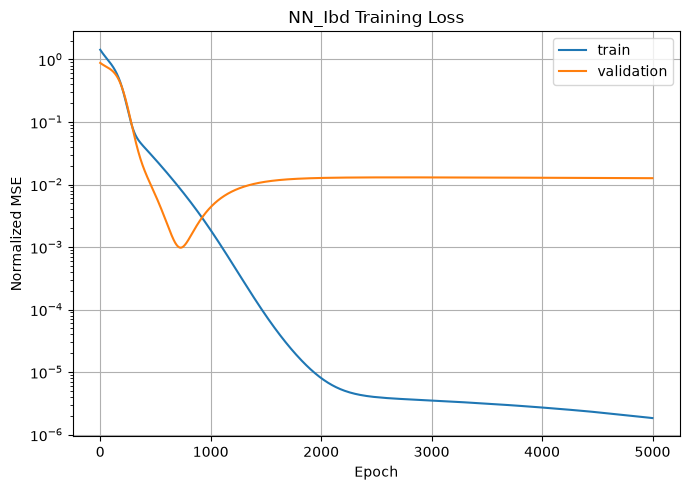

In [13]:
plt.figure(figsize=(7, 5))

plt.semilogy(
    history.train_loss,
    label="train"
)

plt.semilogy(
    history.val_loss,
    label="validation"
)

plt.xlabel("Epoch")
plt.ylabel("Normalized MSE")
plt.title("NN_Ibd Training Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Cell 8 — Predict all measured points

In [14]:
Ibd_pred = predict_ibd(
    model,
    norm,
    Vgs.reshape(-1),
    Vds.reshape(-1),
    device=device,
).cpu().numpy().reshape(-1)

Ibd_true = Ibd.numpy().reshape(-1)

print("prediction points =", len(Ibd_pred))

prediction points = 9


## Cell 9 — Static-model error metrics

In [15]:
error = Ibd_pred - Ibd_true

rmse = np.sqrt(
    np.mean(error ** 2)
)

mae = np.mean(
    np.abs(error)
)

ss_res = np.sum(
    (Ibd_true - Ibd_pred) ** 2
)

ss_tot = np.sum(
    (Ibd_true - np.mean(Ibd_true)) ** 2
)

r2 = (
    1.0 - ss_res / ss_tot
    if ss_tot > 0
    else np.nan
)

print(f"RMSE = {rmse:.8g} A")
print(f"MAE  = {mae:.8g} A")
print(f"R^2  = {r2:.8f}")

RMSE = 0.18986212 A
MAE  = 0.15113567 A
R^2  = 0.99246967


## Cell 10 — Measured Ibd vs ANN-predicted Ibd

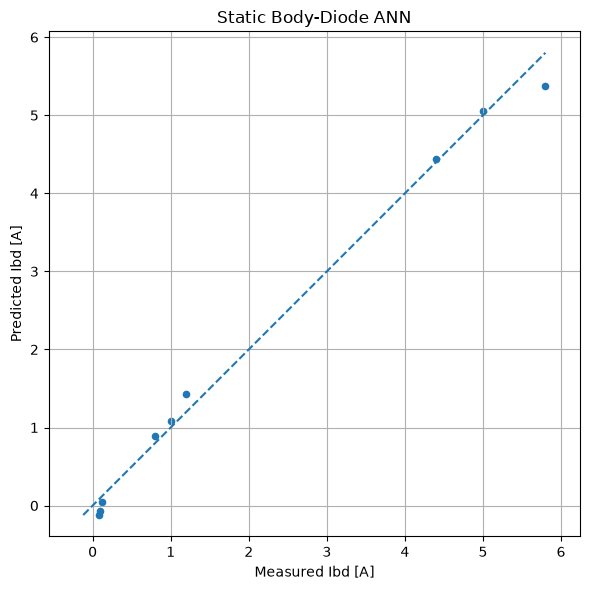

In [16]:
plt.figure(figsize=(6, 6))

plt.scatter(
    Ibd_true,
    Ibd_pred,
    s=20
)

lo = min(
    Ibd_true.min(),
    Ibd_pred.min()
)

hi = max(
    Ibd_true.max(),
    Ibd_pred.max()
)

plt.plot(
    [lo, hi],
    [lo, hi],
    "--"
)

plt.xlabel("Measured Ibd [A]")
plt.ylabel("Predicted Ibd [A]")
plt.title("Static Body-Diode ANN")
plt.grid(True)
plt.axis("equal")
plt.tight_layout()
plt.show()

## Cell 11 — Third-quadrant static curves for each measured Vgs

c:\Users\zipeng\Desktop\NNProject\Neural-Network_Internship_2026\.github\src\body_diode_hybrid.py:339: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  Vds_t = torch.as_tensor(


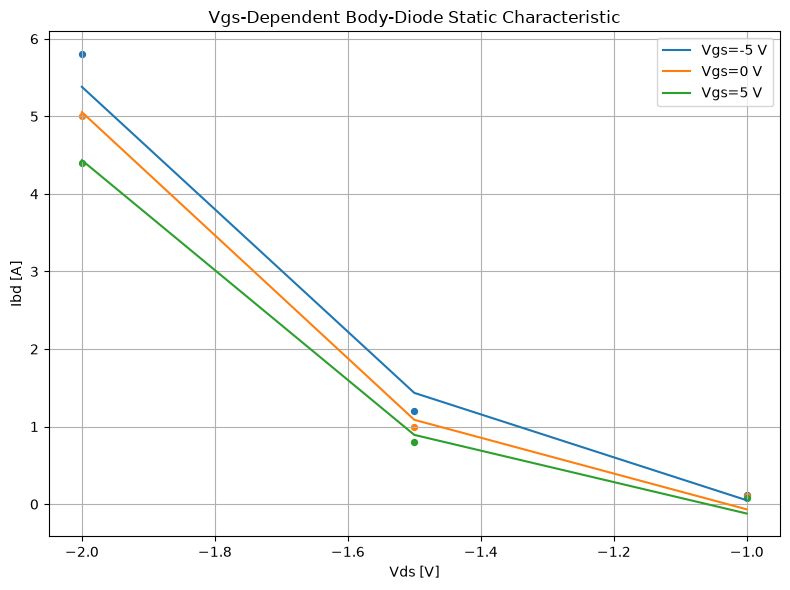

In [17]:
vgs_values = np.sort(
    df[VGS_COL].unique()
)

plt.figure(figsize=(8, 6))

for vgs_value in vgs_values:

    sub = df[
        np.isclose(
            df[VGS_COL].to_numpy(),
            vgs_value
        )
    ].sort_values(VDS_COL)

    vds_curve = sub[
        VDS_COL
    ].to_numpy(dtype=float)

    ibd_measured_curve = sub[
        IBD_COL
    ].to_numpy(dtype=float)

    vgs_curve = np.full(
        len(vds_curve),
        vgs_value,
        dtype=float
    )

    ibd_pred_curve = predict_ibd(
        model,
        norm,
        vgs_curve,
        vds_curve,
        device=device,
    ).cpu().numpy().reshape(-1)

    plt.scatter(
        vds_curve,
        ibd_measured_curve,
        s=18
    )

    plt.plot(
        vds_curve,
        ibd_pred_curve,
        label=f"Vgs={vgs_value:g} V"
    )

plt.xlabel("Vds [V]")
plt.ylabel("Ibd [A]")
plt.title("Vgs-Dependent Body-Diode Static Characteristic")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Cell 12 — Save the trained NN_Ibd model

In [18]:
save_ibd_model(
    MODEL_FILE,
    model,
    norm,
)

print("Saved model:", MODEL_FILE.resolve())

Saved model: C:\Users\zipeng\Desktop\NNProject\Neural-Network_Internship_2026\.github\src\NN_Ibd.pth


## Cell 13 — Lumped-charge parameters

The paper defines:

- \(T_M\): transit time
- \(\tau\): carrier lifetime

These are **device parameters**, not universal constants. Replace the example initial values below with identified/fitted values for your device.

In [19]:
tau = 100e-9   # [s] example placeholder
TM  = 20e-9    # [s] example placeholder

params = LumpedChargeParameters(
    tau=tau,
    TM=TM
)

params.validate()

print("tau =", params.tau, "s")
print("TM  =", params.TM, "s")

tau = 1e-07 s
TM  = 2e-08 s


## Cell 14 — Define a transient input waveform

For a real reverse-recovery simulation, replace these arrays with measured/simulated `Vgs(t)` and `Vds(t)` from your switching test.

Do not trust ANN extrapolation far outside the Vgs/Vds range printed in Cell 4.

In [20]:
dt = 0.2e-9
t_end = 400e-9

time_s = np.arange(
    0.0,
    t_end + dt,
    dt
)

# Demonstration only.
# Keep these values inside your trained static-data voltage domain
# when you use the model quantitatively.
Vgs_TRANSIENT = float(
    df[VGS_COL].iloc[0]
)

Vds_forward = float(
    df[VDS_COL].iloc[
        np.argmax(
            np.abs(
                df[IBD_COL].to_numpy()
            )
        )
    ]
)

Vds_after = float(
    df[VDS_COL].iloc[
        np.argmin(
            np.abs(
                df[IBD_COL].to_numpy()
            )
        )
    ]
)

switch_time = 150e-9

Vgs_waveform = np.full(
    len(time_s),
    Vgs_TRANSIENT
)

Vds_waveform = np.where(
    time_s < switch_time,
    Vds_forward,
    Vds_after
)

print("Transient Vgs =", Vgs_TRANSIENT, "V")
print("Vds before switch =", Vds_forward, "V")
print("Vds after switch  =", Vds_after, "V")

Transient Vgs = 0.0 V
Vds before switch = -2.0 V
Vds after switch  = -1.0 V


## Cell 15 — Run the complete hybrid model: Eqs. (26)–(29)

In [21]:
result = simulate_hybrid_body_diode(
    model,
    norm,
    time_s,
    Vgs_waveform,
    Vds_waveform,
    params,
    device=device,
    initial_qM=None,
    integration="rk4",
)

print(result.keys())

dict_keys(['time_s', 'Vgs_V', 'Vds_V', 'Ibd_static_A', 'qE_C', 'qM_C', 'I_transient_A'])


## Cell 16 — Plot qE and qM

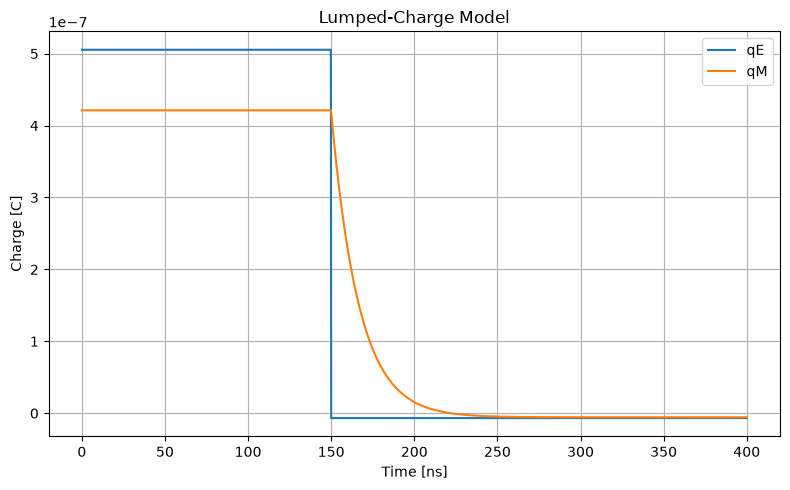

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(
    result["time_s"] * 1e9,
    result["qE_C"],
    label="qE"
)

plt.plot(
    result["time_s"] * 1e9,
    result["qM_C"],
    label="qM"
)

plt.xlabel("Time [ns]")
plt.ylabel("Charge [C]")
plt.title("Lumped-Charge Model")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Cell 17 — Plot static Ibd and transient I(t)

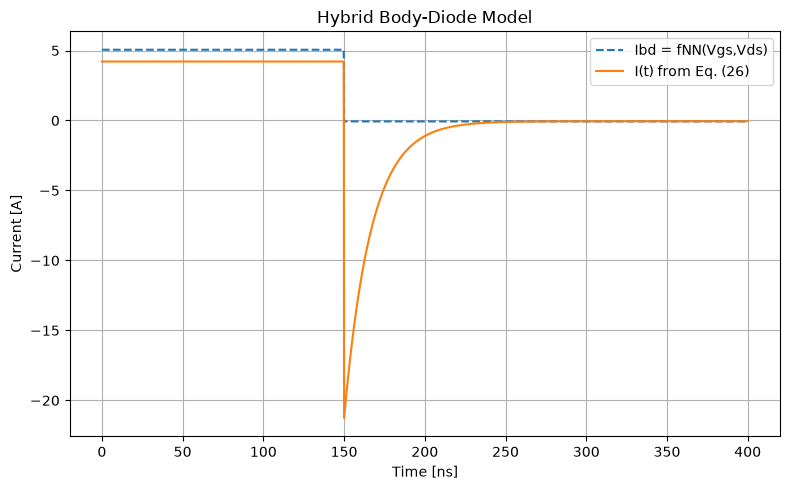

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(
    result["time_s"] * 1e9,
    result["Ibd_static_A"],
    "--",
    label="Ibd = fNN(Vgs,Vds)"
)

plt.plot(
    result["time_s"] * 1e9,
    result["I_transient_A"],
    label="I(t) from Eq. (26)"
)

plt.xlabel("Time [ns]")
plt.ylabel("Current [A]")
plt.title("Hybrid Body-Diode Model")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()